In [24]:
import pandas as pd

In [30]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
data=pd.read_csv("C:/Users/Akshaya/Downloads/messy_telecom_customer_churn.csv")

In [34]:
df=pd.DataFrame(data)
df

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,Churn
0,CUST1000,FEMALE,1,Y,NaN,0.0,59.9,1452.39,month to month,Mailed check,NaN
1,CUST1001,NaN,Yes,NaN,Yes,4.0,64.08,4359.36,month to month,Electronic check,Yes
2,CUST1002,male,0,Yes,NaN,11.0,26.71,7659.02,Month-to-month,credit card,no
3,CUST1003,NaN,0,NaN,NaN,45.0,84.4,1561.20,Two year,Mailed check,Yes
4,CUST1004,NaN,No,N,Yes,33.0,66.2,3670.31,NaN,Electronic check,NaN
...,...,...,...,...,...,...,...,...,...,...,...
205,CUST1007,male,Yes,N,Yes,26.0,59.82,1452.39,NaN,credit card,yes
206,CUST1166,FEMALE,No,Y,No,13.0,89.39,1924.75,month to month,Credit card,no
207,CUST1064,Female,No,No,No,52.0,25.48,3758.94,One year,Electronic check,no
208,CUST1000,FEMALE,1,Y,NaN,0.0,59.9,1452.39,month to month,Mailed check,NaN


In [36]:
df.isna().sum().sort_values(ascending=False)

Dependents        66
Partner           52
Churn             51
Contract          47
PaymentMethod     38
Gender            37
SeniorCitizen     37
TotalCharges       3
MonthlyCharges     2
Tenure             1
CustomerID         0
dtype: int64

In [38]:
df.shape

(210, 11)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      210 non-null    object 
 1   Gender          173 non-null    object 
 2   SeniorCitizen   173 non-null    object 
 3   Partner         158 non-null    object 
 4   Dependents      144 non-null    object 
 5   Tenure          209 non-null    float64
 6   MonthlyCharges  208 non-null    object 
 7   TotalCharges    207 non-null    float64
 8   Contract        163 non-null    object 
 9   PaymentMethod   172 non-null    object 
 10  Churn           159 non-null    object 
dtypes: float64(2), object(9)
memory usage: 18.2+ KB


## Making values consistent across columns and filling null values.

In [43]:
df['Gender'].unique()

array(['FEMALE', nan, 'male ', 'Female', 'Male'], dtype=object)

In [45]:
df["Gender"] = df["Gender"].str.strip().str.lower()  # str.strip()=removes whitespaces from the strings in each row

In [47]:
df['Gender'].unique()

array(['female', nan, 'male'], dtype=object)

In [49]:
df['SeniorCitizen'].unique()

array(['1', 'Yes', '0', 'No', nan], dtype=object)

In [51]:
df['SeniorCitizen']=df['SeniorCitizen'].str.strip().str.lower()

In [53]:
df['SeniorCitizen']=df['SeniorCitizen'].map({'yes':1,'no':0})

In [55]:
df['SeniorCitizen'].unique()

array([nan,  1.,  0.])

In [57]:
df['Partner'].unique()

array(['Y', nan, 'Yes', 'N', 'No'], dtype=object)

In [59]:
df['Partner']=df['Partner'].map({'Y':'Yes','N':'No'})

In [61]:
df['Partner']=df['Partner'].map({'Yes':1,'No':0})

In [63]:
df['Partner'].unique()

array([ 1., nan,  0.])

In [65]:
df['Dependents'].unique()

array([nan, 'Yes', 'No'], dtype=object)

In [67]:
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})

In [69]:
df['Churn'].unique()

array([nan, 'Yes', 'no', 'yes', 'No'], dtype=object)

In [71]:
df["Churn"] = df["Churn"].str.strip().str.lower()

In [73]:
df["Churn"] = df["Churn"].map({"yes": 1, "no": 0})       

In [75]:
df['Churn'].unique()

array([nan,  1.,  0.])

In [77]:
df['Tenure'].unique()  

array([ 0.,  4., 11., 45., 33., 48., 44., 26., 72., 25., 46., 55., 62.,
       47., 60., 35.,  7., 51., 13., 27.,  1., 58.,  6.,  2., 22., 17.,
       37., 14., 63., 73., 38., 56., 16., 43., 24., 12., 67.,  9., 66.,
       39., 41., 40.,  5., 69., 32., 52., 21., 20.,  3., 74., 61., 23.,
       54.,  8., 30., 65., 50., 18., 19., 36., 10., -5., 49., 64., 34.,
       68., 59., nan, 71., 29., 31., 28.])

In [79]:
df['Tenure']=pd.to_numeric(df['Tenure'],errors='coerce')

In [81]:
df['Tenure'].unique() 

array([ 0.,  4., 11., 45., 33., 48., 44., 26., 72., 25., 46., 55., 62.,
       47., 60., 35.,  7., 51., 13., 27.,  1., 58.,  6.,  2., 22., 17.,
       37., 14., 63., 73., 38., 56., 16., 43., 24., 12., 67.,  9., 66.,
       39., 41., 40.,  5., 69., 32., 52., 21., 20.,  3., 74., 61., 23.,
       54.,  8., 30., 65., 50., 18., 19., 36., 10., -5., 49., 64., 34.,
       68., 59., nan, 71., 29., 31., 28.])

In [83]:
df=df[df['Tenure']>=0]

In [85]:
df['MonthlyCharges'].unique() 

array(['59.9', '64.08', '26.71', '84.4', '66.2', '61.46', '99.99',
       '59.82', '103.02', '22.71', '42.2', '92.0', '59.73', '62.41',
       '114.73', '38.19', '78.34', '54.21', '81.15', '60.87', '72.44',
       '35.25', '83.23', '69.84', '79.03', '79.54', '113.44', '60.08',
       '93.64', '89.67', '74.27', '85.27', '21.31', '95.0', '87.19',
       '57.33', '78.62', '20.46', '107.21', '21.3', '42.93', '38.14',
       '57.97', '118.48', '93.75', '86.81', '25.48', '47.07', '71.88',
       '90.72', '35.34', '60.94', '34.99', '85.89', '80.67', '53.52',
       '35.62', nan, '75.2', '37.64', '100.29', '76.51', '82.41', '56.24',
       '59.72', '111.99', '106.18', '112.25', '40.5', '35.52', '54.57',
       '75.96', '65.08', '112.08', '78.06', '103.89', '54.63', '34.87',
       '119.69', '32.75', '21.97', '54.18', '113.21', '99.73', '89.39',
       ' ', '28.55', '116.11', '104.65', '22.65', '111.48', '28.53',
       '43.11', '31.32', '84.11', '67.21', '109.27', '92.23', '45.18',
       '97.

In [87]:
import numpy as np

In [89]:
df.replace([" ", "", "NA"], np.nan, inplace=True)

In [91]:
df['MonthlyCharges'] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")     

In [93]:
df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(),inplace=True)

In [95]:
df['MonthlyCharges'].dtype

dtype('float64')

In [97]:
df['MonthlyCharges'].unique()

array([ 59.9 ,  64.08,  26.71,  84.4 ,  66.2 ,  61.46,  99.99,  59.82,
       103.02,  22.71,  42.2 ,  92.  ,  59.73,  62.41, 114.73,  38.19,
        78.34,  54.21,  81.15,  60.87,  72.44,  35.25,  83.23,  69.84,
        79.03,  79.54, 113.44,  60.08,  93.64,  89.67,  74.27,  85.27,
        21.31,  95.  ,  87.19,  57.33,  78.62,  20.46, 107.21,  21.3 ,
        42.93,  38.14,  57.97, 118.48,  93.75,  86.81,  25.48,  47.07,
        71.88,  90.72,  35.34,  60.94,  34.99,  85.89,  80.67,  53.52,
        35.62,  67.21,  75.2 ,  37.64, 100.29,  76.51,  82.41,  56.24,
        59.72, 111.99, 106.18, 112.25,  40.5 ,  35.52,  54.57,  75.96,
        65.08, 112.08,  78.06, 103.89,  54.63,  34.87, 119.69,  32.75,
        21.97,  54.18, 113.21,  99.73,  89.39,  28.55, 116.11, 104.65,
        22.65, 111.48,  28.53,  43.11,  31.32,  84.11, 109.27,  92.23,
        45.18,  97.55,  43.82,  37.85,  70.22, 109.63,  65.22, 107.68,
       101.74,  34.09,  40.99,  62.14,  29.94,  54.7 ,  86.35,  79.13])

In [99]:
df['TotalCharges'].unique() 

array([1452.39, 4359.36, 7659.02, 1561.2 , 3670.31, 7253.98, 7706.63,
        298.22, 1299.99, 6836.59, 4355.  , 7931.97, 4209.75,     nan,
       4131.68, 6722.78, 3026.03, 6613.12, 7442.12,   28.22, 6947.07,
       2281.08, 6563.18, 2509.38,  864.56, 3717.78, 3939.67, 4487.56,
       4763.28, 6314.68, 6820.5 , 5045.63, 7157.95,  302.67, 3799.12,
       7716.87,  409.29, 5725.09, 4458.33,  835.51,  691.1 , 6918.65,
       6553.06, 3149.37, 6171.42, 1859.94, 6057.95, 2035.02, 1645.54,
        482.21, 3469.28, 1618.87, 7921.38, 3758.94, 4138.31,  616.06,
       2685.39, 4225.65, 7278.01, 3085.04, 1844.43, 2987.23, 1924.75,
       3081.23, 6187.13,  313.12,  269.79, 1977.38, 4991.04, 6648.53,
       4786.25, 1746.27, 1045.02, 5800.89, 7161.47, 3782.83, 5876.6 ,
       6172.45,  893.56, 4510.75, 2265.5 , 1406.55, 4179.66, 6822.27,
       1275.58, 7454.08, 6861.73, 6034.52,  980.3 , 3578.75, 7181.54,
       7579.44, 1529.99,   60.56, 6553.91, 2401.03, 5571.8 , 1347.69,
       6883.81, 4270

In [101]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [103]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)  

In [105]:
df['Contract'] = df['Contract'].str.strip().str.title()

In [107]:
df['Contract']=df['Contract'].replace({'Month To Month':'Month-To-Month'})

In [109]:
df['PaymentMethod'].unique() 

array(['Mailed check', 'Electronic check', 'credit card', 'Bank transfer',
       'Credit card', nan], dtype=object)

In [111]:
df['Contract']=df['Contract'].replace({'credit card':'Credit card'})

In [113]:
df["PaymentMethod"].fillna(df["PaymentMethod"].mode()[0], inplace=True)   

In [115]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,Churn
0,CUST1000,female,NaN,1.0,NaN,0.0,59.90,1452.39,Month-To-Month,Mailed check,NaN
1,CUST1001,NaN,1.0,NaN,1.0,4.0,64.08,4359.36,Month-To-Month,Electronic check,1.0
2,CUST1002,male,NaN,NaN,NaN,11.0,26.71,7659.02,Month-To-Month,credit card,0.0
3,CUST1003,NaN,NaN,NaN,NaN,45.0,84.40,1561.20,Two Year,Mailed check,1.0
4,CUST1004,NaN,0.0,0.0,1.0,33.0,66.20,3670.31,NaN,Electronic check,NaN


In [117]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

In [119]:
df["Contract"].fillna("Unknown", inplace=True)

In [121]:
df["PaymentMethod"].fillna("Unknown", inplace=True)

In [123]:
df.isna().sum().sort_values(ascending=False)

Partner           133
SeniorCitizen     121
Dependents         66
Churn              50
CustomerID          0
Gender              0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
dtype: int64

In [125]:
(df[["Partner", "Dependents", "Contract", "PaymentMethod"]]    
.isnull()
.mean() * 100)

Partner          63.942308
Dependents       31.730769
Contract          0.000000
PaymentMethod     0.000000
dtype: float64

In [127]:
df.drop(columns=["Partner"], inplace=True)

In [129]:
df['Dependents_missing']=df['Dependents'].isnull().astype(int)

In [131]:
df['Dependents_missing']

0      1
1      0
2      1
3      1
4      0
      ..
205    0
206    0
207    0
208    1
209    1
Name: Dependents_missing, Length: 208, dtype: int32

In [133]:
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)

In [135]:
(df[['Churn']].isnull().mean() * 100)

Churn    24.038462
dtype: float64

In [137]:
df=df[df['Churn'].notna()]

In [139]:
df.isna().sum()

CustomerID             0
Gender                 0
SeniorCitizen         93
Dependents             0
Tenure                 0
MonthlyCharges         0
TotalCharges           0
Contract               0
PaymentMethod          0
Churn                  0
Dependents_missing     0
dtype: int64

In [141]:
(df[['SeniorCitizen']].isnull().mean() * 100)

SeniorCitizen    58.860759
dtype: float64

In [143]:
df["SeniorCitizen_missing"] = df["SeniorCitizen"].isnull().astype(int)
df["SeniorCitizen"].fillna(df["SeniorCitizen"].mode()[0], inplace=True)

In [145]:
df[df.duplicated()]

,CustomerID,Gender,SeniorCitizen,Dependents,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,Churn,Dependents_missing,SeniorCitizen_missing
201,CUST1151,male,0.0,1.0,10.0,109.27,3717.78,Month-To-Month,Electronic check,0.0,0,1
202,CUST1165,female,0.0,0.0,38.0,54.63,409.29,Unknown,Mailed check,0.0,0,1
203,CUST1006,male,0.0,1.0,44.0,99.99,7706.63,Month-To-Month,Bank transfer,1.0,1,1
204,CUST1108,male,0.0,1.0,36.0,21.97,4359.36,Month-To-Month,Electronic check,0.0,1,1
205,CUST1007,male,1.0,1.0,26.0,59.82,1452.39,Unknown,credit card,1.0,0,0
206,CUST1166,female,0.0,0.0,13.0,89.39,1924.75,Month-To-Month,Credit card,0.0,0,0
207,CUST1064,female,0.0,0.0,52.0,25.48,3758.94,One Year,Electronic check,0.0,0,0
209,CUST1040,female,1.0,1.0,16.0,107.21,5045.63,Month-To-Month,Mailed check,0.0,1,0


In [147]:
df.drop_duplicates(inplace=True)

## EDA

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

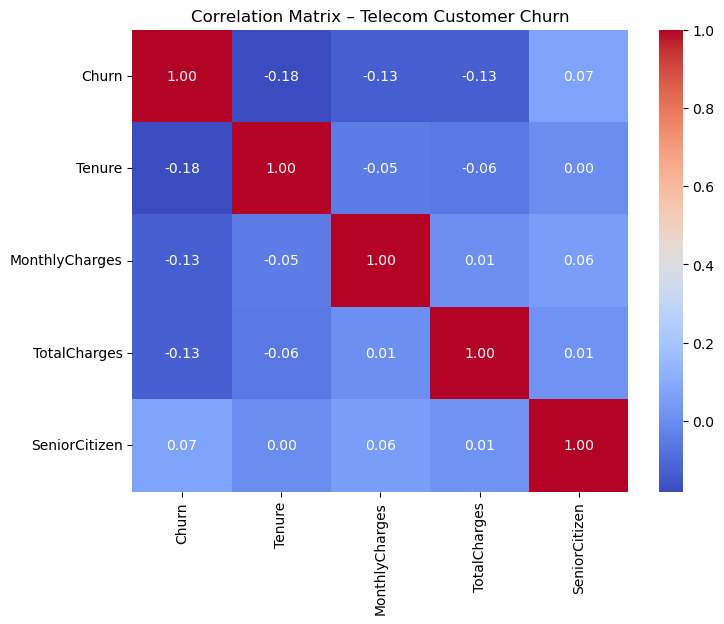

In [152]:
# correlation matrix
cor_mat=df[['Churn','Tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Telecom Customer Churn")
plt.show()

In [153]:
df['Churn'].value_counts()

Churn
0.0    81
1.0    69
Name: count, dtype: int64

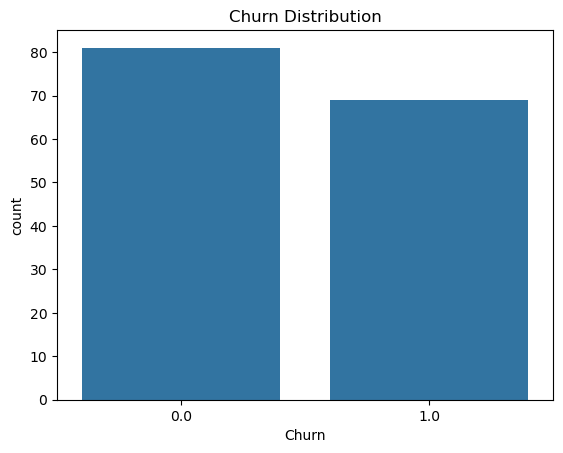

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


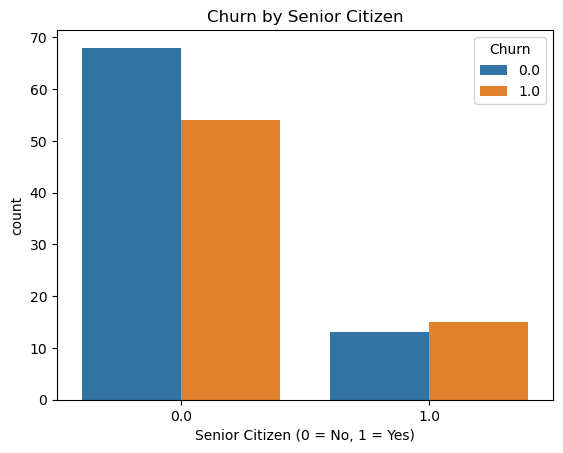

In [155]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.show()

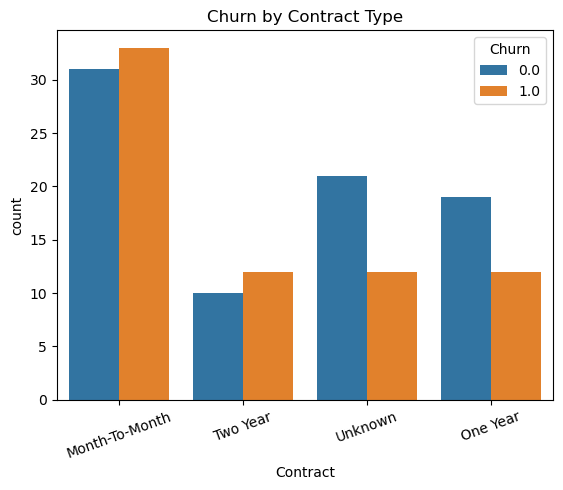

In [156]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

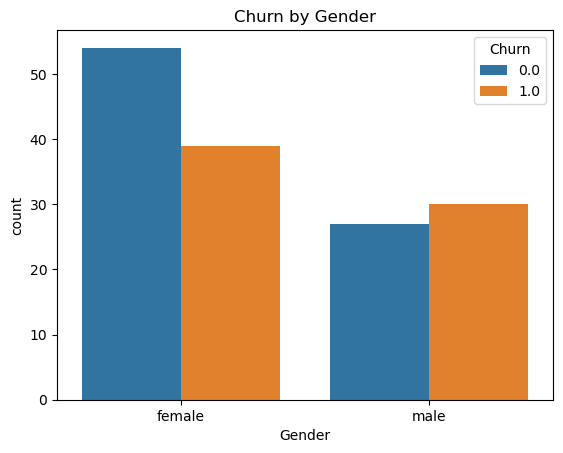

In [157]:
sns.countplot(x="Gender",hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

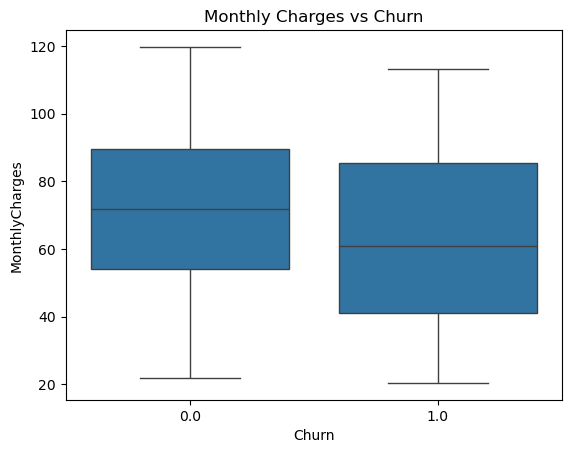

In [158]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

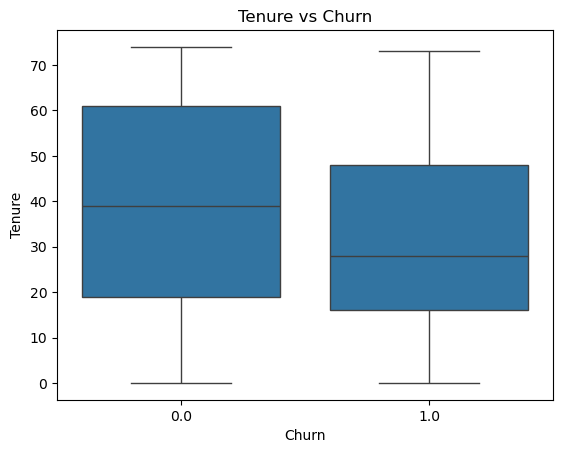

In [159]:
sns.boxplot(x="Churn", y="Tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

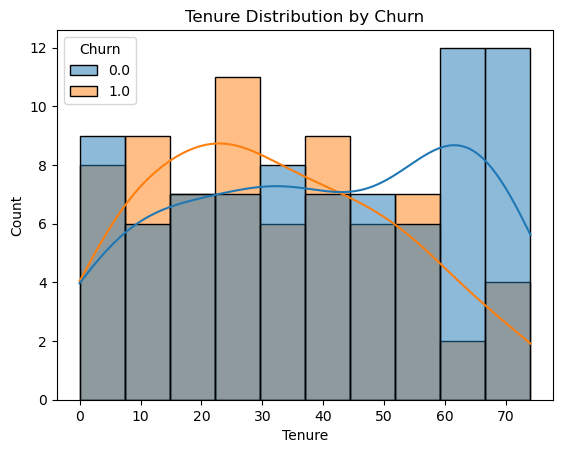

In [160]:
sns.histplot(data=df, x="Tenure", hue="Churn", bins=10,kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

In [161]:
df['Tenure'].unique()

array([ 4., 11., 45., 48., 44., 26., 72., 25., 62., 60., 35.,  0., 51.,
       46., 55., 27.,  1., 13.,  6.,  2., 22., 17., 14., 63., 73., 38.,
       56., 16., 24., 12.,  9., 66., 33.,  7., 39., 41., 40., 58., 69.,
       52., 20., 61., 23., 30., 65., 74., 50., 43., 67., 18., 19., 36.,
       32., 49., 64., 37., 34., 68., 59.,  8., 21., 10., 29.,  3., 31.,
        5., 71., 28., 54.])

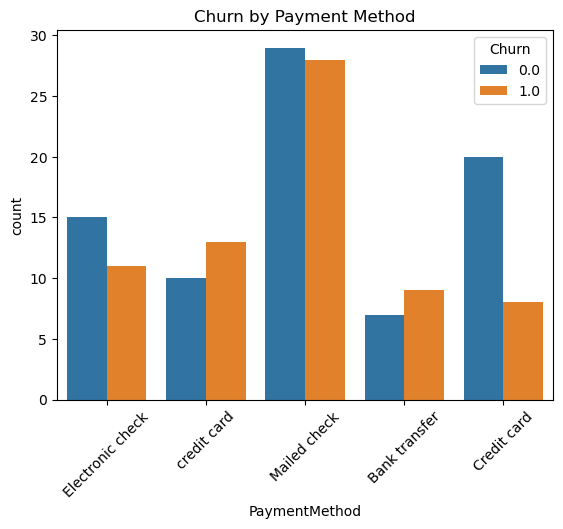

In [162]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()


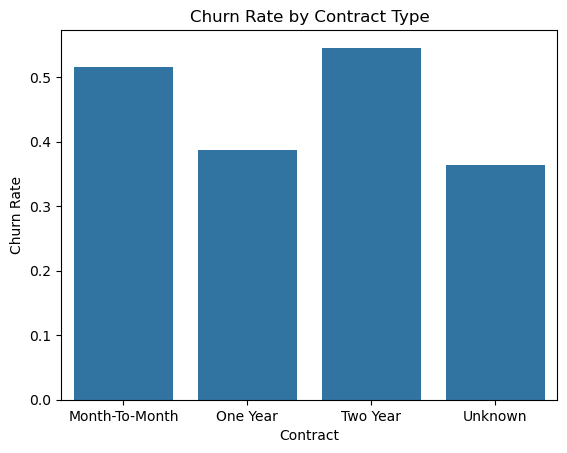

In [163]:
churn_rate = (df.groupby("Contract")["Churn"].mean().reset_index())

sns.barplot(x="Contract", y="Churn", data=churn_rate)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()


## Insights & Conclusion
